# Driver Drowsiness Detection Using Eye Closure and Yawning Analysis with Deep Learning

## Submitted By:
Govindarajan S

## Technologies Used
- Python
- TensorFlow
- Keras
- CNN
- MobileNetV2
- Computer Vision

## Dataset Description

The dataset contains four classes:

- Open
- Closed
- no_yawn
- yawn

The data is divided into Train, Validation and Test sets.

In [28]:
from pathlib import Path
from collections import Counter
import hashlib
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout,Flatten
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_CANDIDATES = [
    Path("Dataset/CleanSplit"),
    Path(r"C:\Guvi - Projrects\Project  - 5\Dataset\CleanSplit")
]
DATA_ROOT = next((p for p in DATA_CANDIDATES if p.is_dir()), DATA_CANDIDATES[0])
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "Validation"
TEST_DIR = DATA_ROOT / "Test"
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

for folder in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    if not folder.is_dir():
        raise FileNotFoundError(f"Missing dataset folder: {folder.resolve()}")

CLASS_NAMES = sorted(p.name for p in TRAIN_DIR.iterdir() if p.is_dir())
print("Classes:", CLASS_NAMES)
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


Classes: ['Closed', 'Open', 'no_yawn', 'yawn']
TensorFlow: 2.22.0-rc0
GPU devices: []


Exact duplicates train/validation: 0
Exact duplicates train/test: 0
Exact duplicates validation/test: 0
Train {'Closed': 508, 'Open': 508, 'no_yawn': 507, 'yawn': 506}
Validation {'Closed': 108, 'Open': 108, 'no_yawn': 108, 'yawn': 108}
Test {'Closed': 110, 'Open': 110, 'no_yawn': 110, 'yawn': 109}


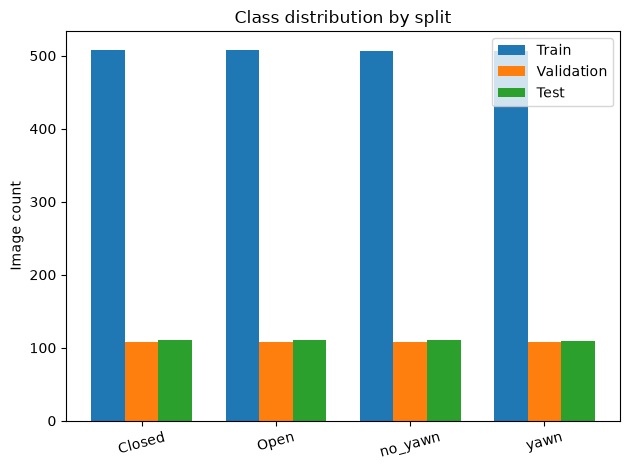

In [8]:
# Verify that no exact image file content occurs in more than one split.
def folder_hashes(folder):
    result = set()
    for path in Path(folder).rglob("*"):
        if path.is_file():
            digest = hashlib.sha256(path.read_bytes()).hexdigest()
            result.add(digest)
    return result

split_hashes = {name: folder_hashes(path) for name, path in {
    "train": TRAIN_DIR, "validation": VAL_DIR, "test": TEST_DIR
}.items()}

for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    overlap = split_hashes[left] & split_hashes[right]
    print(f"Exact duplicates {left}/{right}: {len(overlap)}")
    assert not overlap, f"Found exact duplicate images in {left} and {right}."

# Display class counts for the three partitions.
counts = {}
for split_name, folder in (("Train", TRAIN_DIR), ("Validation", VAL_DIR), ("Test", TEST_DIR)):
    counts[split_name] = [sum(1 for p in (folder / name).iterdir() if p.is_file()) for name in CLASS_NAMES]
    print(split_name, dict(zip(CLASS_NAMES, counts[split_name])))

x = np.arange(len(CLASS_NAMES))
width = 0.25
for j, (split_name, values) in enumerate(counts.items()):
    plt.bar(x + (j - 1) * width, values, width, label=split_name)
plt.xticks(x, CLASS_NAMES, rotation=15)
plt.ylabel("Image count")
plt.title("Class distribution by split")
plt.legend()
plt.tight_layout()
plt.show()


## Data Preprocessing

The following preprocessing techniques were applied:

- Image resizing (224×224)
- Normalisation
- Data augmentation
    - Rotation
    - Zoom
    - Brightness variation
    - Horizontal Flipping

In [9]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Custom CNN inputs are scaled to [0, 1].
def custom_generators():
    train_aug = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=(0.8, 1.2)
    )
    plain = ImageDataGenerator(rescale=1./255)
    train = train_aug.flow_from_directory(
        TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", seed=SEED
    )
    val = plain.flow_from_directory(
        VAL_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=False
    )
    test = plain.flow_from_directory(
        TEST_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=False
    )
    return train, val, test

# MobileNetV2 inputs use preprocess_input, not rescale=1./255.
def mobilenet_generators():
    train_aug = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=10,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=(0.8, 1.2)
    )
    plain = ImageDataGenerator(preprocessing_function=preprocess_input)
    train = train_aug.flow_from_directory(
        TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", seed=SEED
    )
    val = plain.flow_from_directory(
        VAL_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=False
    )
    test = plain.flow_from_directory(
        TEST_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=False
    )
    return train, val, test

custom_train, custom_val, custom_test = custom_generators()
mobile_train, mobile_val, mobile_test = mobilenet_generators()

expected_indices = custom_train.class_indices
for generator in (custom_val, custom_test, mobile_train, mobile_val, mobile_test):
    assert generator.class_indices == expected_indices, "Class index mappings differ."
print("Class mapping:", expected_indices)


Found 2029 images belonging to 4 classes.
Found 432 images belonging to 4 classes.
Found 439 images belonging to 4 classes.
Found 2029 images belonging to 4 classes.
Found 432 images belonging to 4 classes.
Found 439 images belonging to 4 classes.
Class mapping: {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


## Custom CNN Architecture

A custom CNN was developed using:

- 3 Convolution Layers
- MaxPooling Layers
- Dense Layer
- Dropout
- Softmax Output Layer

In [22]:
def build_custom_cnn(num_classes):
    return Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.4),

    Dense(num_classes,activation='softmax')
])
custom_model = build_custom_cnn(len(CLASS_NAMES))
custom_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start_time = time.time()
custom_history = custom_model.fit(
    custom_train,
    validation_data=custom_val,
    epochs=15,
    callbacks=[early_stop]
)
custom_training_seconds = time.time() - start_time
custom_model.save(MODEL_DIR / "custom_cnn_4class.keras")
print(f"Custom CNN training time: {custom_training_seconds / 60:.1f} minutes")

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 527ms/step - accuracy: 0.5692 - loss: 0.9433 - val_accuracy: 0.7315 - val_loss: 0.5502
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 512ms/step - accuracy: 0.7649 - loss: 0.4907 - val_accuracy: 0.8079 - val_loss: 0.3813
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 499ms/step - accuracy: 0.7797 - loss: 0.4173 - val_accuracy: 0.8287 - val_loss: 0.3583
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 512ms/step - accuracy: 0.7866 - loss: 0.3933 - val_accuracy: 0.8079 - val_loss: 0.3668
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 516ms/step - accuracy: 0.8014 - loss: 0.3632 - val_accuracy: 0.7986 - val_loss: 0.3589
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 506ms/step - accuracy: 0.8112 - loss: 0.3494 - val_accuracy: 0.8403 - val_loss: 0.3363
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 501ms/step - accuracy: 0.8206 - loss: 0.3371 - val_accuracy: 0.8148 - val_loss: 0.3277
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 519ms/step - accuracy: 0.8221 - loss: 0.3455 - val_accu

## MobileNetV2 Transfer Learning

MobileNetV2 was selected because it provides
pre-trained ImageNet weights and better
generalisation performance.

In [29]:
def build_mobilenet_classifier(num_classes):
    backbone = MobileNetV2(
        weights="imagenet", include_top=False, input_shape=(224, 224, 3)
    )
    backbone.trainable = False
    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ], name="mobilenetv2_classifier")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

mobilenet_model = build_mobilenet_classifier(len(CLASS_NAMES))
mobile_early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
start = time.time()
mobilenet_history = mobilenet_model.fit(
    mobile_train,
    validation_data=mobile_val,
    epochs=15,
    callbacks=[mobile_early_stop]
)
mobilenet_training_seconds = time.time() - start
mobilenet_model.save(MODEL_DIR / "mobilenetv2_4class.keras")
print(f"MobileNetV2 training time: {mobilenet_training_seconds / 60:.1f} minutes")


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 547ms/step - accuracy: 0.7097 - loss: 0.6326 - val_accuracy: 0.8310 - val_loss: 0.3200
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 474ms/step - accuracy: 0.8236 - loss: 0.3473 - val_accuracy: 0.8727 - val_loss: 0.2832
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 476ms/step - accuracy: 0.8428 - loss: 0.3070 - val_accuracy: 0.8843 - val_loss: 0.2587
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 467ms/step - accuracy: 0.8571 - loss: 0.2839 - val_accuracy: 0.8750 - val_loss: 0.2489
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 463ms/step - accuracy: 0.8659 - loss: 0.2680 - val_accuracy: 0.8889 - val_loss: 0.2358
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 488ms/step - accuracy: 0.8881 - loss: 0.2402 - val_accuracy: 0.8449 - val_loss: 0.2883
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 479ms/step - accuracy: 0.8753 - loss: 0.2563 - val_accuracy: 0.8657 - val_loss: 0.2581
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 468ms/step - accuracy: 0.8876 - loss: 0.2369 - val_accu

## Evaluation Metrics

The following metrics were used:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

## Error Analysis

Misclassified samples were analysed to understand model limitations.

Common reasons include:

- Poor lighting conditions
- Partial eye closure
- Small mouth opening
- Facial pose variations

Found 2029 images belonging to 4 classes.
Found 2029 images belonging to 4 classes.

Custom CNN - training: loss=0.2707, accuracy=0.8571
              precision    recall  f1-score   support

      Closed       0.95      0.99      0.97       508
        Open       0.99      0.95      0.97       508
     no_yawn       0.67      0.95      0.79       507
        yawn       0.91      0.54      0.68       506

    accuracy                           0.86      2029
   macro avg       0.88      0.86      0.85      2029
weighted avg       0.88      0.86      0.85      2029



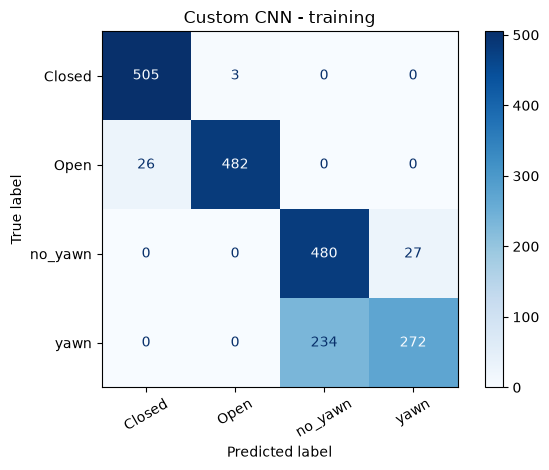


Custom CNN - validation: loss=0.2960, accuracy=0.8426
              precision    recall  f1-score   support

      Closed       0.96      0.98      0.97       108
        Open       0.99      0.96      0.98       108
     no_yawn       0.65      0.93      0.76       108
        yawn       0.87      0.50      0.64       108

    accuracy                           0.84       432
   macro avg       0.87      0.84      0.84       432
weighted avg       0.87      0.84      0.84       432



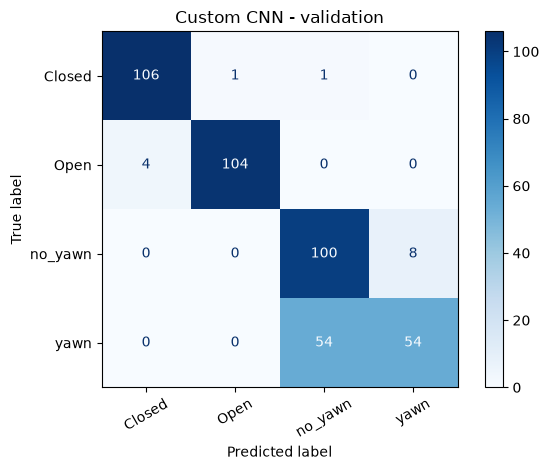


Custom CNN - independent test: loss=0.3122, accuracy=0.8246
              precision    recall  f1-score   support

      Closed       0.96      0.99      0.97       110
        Open       0.99      0.95      0.97       110
     no_yawn       0.62      0.94      0.74       110
        yawn       0.87      0.41      0.56       109

    accuracy                           0.82       439
   macro avg       0.86      0.82      0.81       439
weighted avg       0.86      0.82      0.81       439



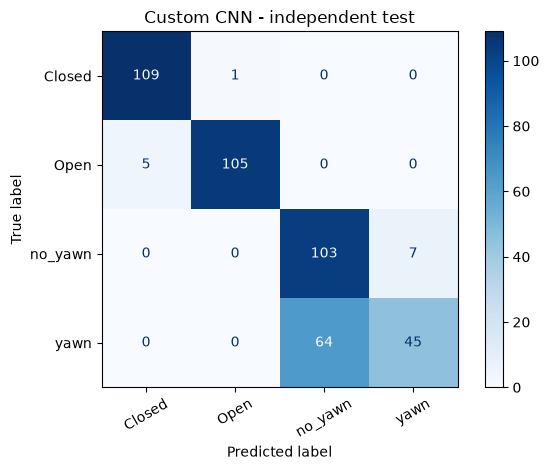


MobileNetV2 - training: loss=0.1583, accuracy=0.9335
              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00       508
        Open       1.00      1.00      1.00       508
     no_yawn       0.81      0.97      0.88       507
        yawn       0.96      0.77      0.86       506

    accuracy                           0.93      2029
   macro avg       0.94      0.93      0.93      2029
weighted avg       0.94      0.93      0.93      2029



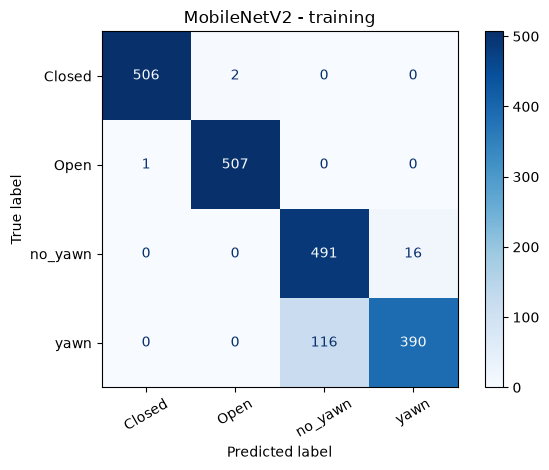


MobileNetV2 - validation: loss=0.1975, accuracy=0.9097
              precision    recall  f1-score   support

      Closed       0.99      0.99      0.99       108
        Open       0.99      0.99      0.99       108
     no_yawn       0.76      0.95      0.85       108
        yawn       0.94      0.70      0.80       108

    accuracy                           0.91       432
   macro avg       0.92      0.91      0.91       432
weighted avg       0.92      0.91      0.91       432



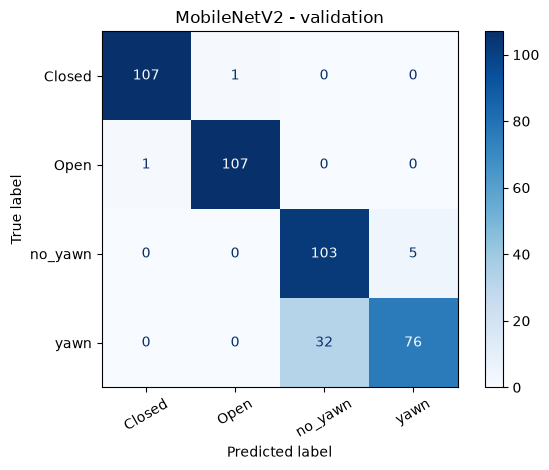


MobileNetV2 - independent test: loss=0.1979, accuracy=0.9089
              precision    recall  f1-score   support

      Closed       1.00      0.99      1.00       110
        Open       0.99      1.00      1.00       110
     no_yawn       0.74      0.98      0.85       110
        yawn       0.97      0.66      0.79       109

    accuracy                           0.91       439
   macro avg       0.93      0.91      0.91       439
weighted avg       0.93      0.91      0.91       439



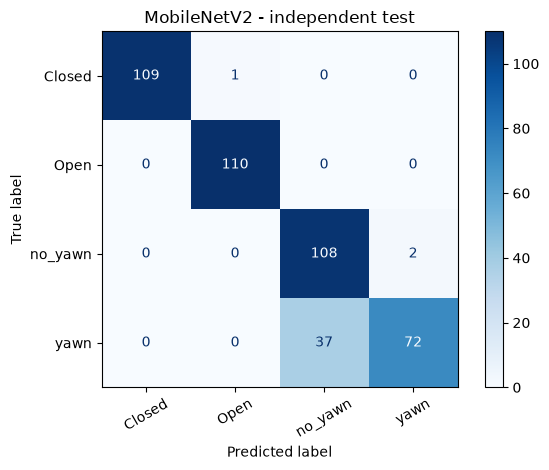


===== Custom CNN Error Analysis =====

Total Misclassifications: 77
Sample 11: Actual = Closed | Predicted = Open
Sample 119: Actual = Open | Predicted = Closed
Sample 126: Actual = Open | Predicted = Closed
Sample 130: Actual = Open | Predicted = Closed
Sample 160: Actual = Open | Predicted = Closed
Sample 214: Actual = Open | Predicted = Closed
Sample 239: Actual = no_yawn | Predicted = yawn
Sample 240: Actual = no_yawn | Predicted = yawn
Sample 241: Actual = no_yawn | Predicted = yawn
Sample 251: Actual = no_yawn | Predicted = yawn

===== MobileNetV2 Error Analysis =====

Total Misclassifications: 40
Sample 99: Actual = Closed | Predicted = Open
Sample 238: Actual = no_yawn | Predicted = yawn
Sample 317: Actual = no_yawn | Predicted = yawn
Sample 336: Actual = yawn | Predicted = no_yawn
Sample 338: Actual = yawn | Predicted = no_yawn
Sample 339: Actual = yawn | Predicted = no_yawn
Sample 344: Actual = yawn | Predicted = no_yawn
Sample 345: Actual = yawn | Predicted = no_yawn
Sample

In [31]:
def evaluate_classifier(model, generator, title, show_matrix=True):
    generator.reset()
    loss, accuracy = model.evaluate(generator, verbose=0)
    generator.reset()
    probabilities = model.predict(generator, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    labels = generator.classes
    names = list(generator.class_indices.keys())
    print(f"\n{title}: loss={loss:.4f}, accuracy={accuracy:.4f}")
    print(classification_report(labels, predictions, target_names=names, zero_division=0))
    matrix = confusion_matrix(labels, predictions)
    if show_matrix:
        ConfusionMatrixDisplay(matrix, display_labels=names).plot(cmap="Blues", xticks_rotation=30)
        plt.title(title)
        plt.tight_layout()
        plt.show()
    return {"loss": loss, "accuracy": accuracy, "labels": labels, "predictions": predictions, "matrix": matrix}

# Non-augmented training generators make train-vs-held-out generalization comparable.
plain_custom = ImageDataGenerator(rescale=1./255)
custom_train_eval = plain_custom.flow_from_directory(
    TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
plain_mobile = ImageDataGenerator(preprocessing_function=preprocess_input)
mobile_train_eval = plain_mobile.flow_from_directory(
    TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
custom_train_result = evaluate_classifier(custom_model, custom_train_eval, "Custom CNN - training")
custom_val_result = evaluate_classifier(custom_model, custom_val, "Custom CNN - validation")
custom_test_result = evaluate_classifier(custom_model, custom_test, "Custom CNN - independent test")
mobile_train_result = evaluate_classifier(mobilenet_model, mobile_train_eval, "MobileNetV2 - training")
mobile_val_result = evaluate_classifier(mobilenet_model, mobile_val, "MobileNetV2 - validation")
mobile_test_result = evaluate_classifier(mobilenet_model, mobile_test, "MobileNetV2 - independent test")

# ====================================================
# Error Analysis
# ====================================================

def error_analysis(result_dict, class_names):
    labels = result_dict["labels"]
    preds = result_dict["predictions"]

    errors = np.where(labels != preds)[0]

    print(f"\nTotal Misclassifications: {len(errors)}")

    for idx in errors[:10]:   # Show first 10 errors

        print(
            f"Sample {idx}: "
            f"Actual = {class_names[labels[idx]]} | "
            f"Predicted = {class_names[preds[idx]]}"
        )

# Run error analysis
class_names = CLASS_NAMES

print("\n===== Custom CNN Error Analysis =====")
error_analysis(custom_test_result, class_names)

print("\n===== MobileNetV2 Error Analysis =====")
error_analysis(mobile_test_result, class_names)


comparison = [
    ("Custom CNN", custom_training_seconds, custom_train_result["accuracy"], custom_val_result["accuracy"], custom_test_result["accuracy"]),
    ("MobileNetV2", mobilenet_training_seconds, mobile_train_result["accuracy"], mobile_val_result["accuracy"], mobile_test_result["accuracy"])
]
print("\nModel comparison (same clean split)")
print(f"{'Model':<14} {'Minutes':>9} {'Train acc':>11} {'Val acc':>10} {'Test acc':>10}")
for name, seconds, train_acc, val_acc, test_acc in comparison:
    print(f"{name:<14} {seconds/60:>9.1f} {train_acc:>11.3f} {val_acc:>10.3f} {test_acc:>10.3f}")


Found 1016 images belonging to 2 classes.
Found 216 images belonging to 2 classes.
Found 220 images belonging to 2 classes.
Epoch 1/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 567ms/step - accuracy: 0.7785 - loss: 0.4723 - val_accuracy: 0.9722 - val_loss: 0.1159
Epoch 2/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 460ms/step - accuracy: 0.9636 - loss: 0.1069 - val_accuracy: 0.9815 - val_loss: 0.0742
Epoch 3/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 452ms/step - accuracy: 0.9774 - loss: 0.0746 - val_accuracy: 0.9815 - val_loss: 0.0628
Epoch 4/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 479ms/step - accuracy: 0.9813 - loss: 0.0592 - val_accuracy: 0.9815 - val_loss: 0.0568
Epoch 5/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 463ms/step - accuracy: 0.9843 - loss: 0.0471 - val_accuracy: 0.9815 - val_loss: 0.0513
Epoch 6/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 473ms/step - accuracy: 0.9823 - loss: 0.0518 - val_accuracy: 0.9861 - val_loss: 0.0450
Epoch 7/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 463ms/step - accuracy: 0.9892 - loss: 0.0439 - val_accuracy:

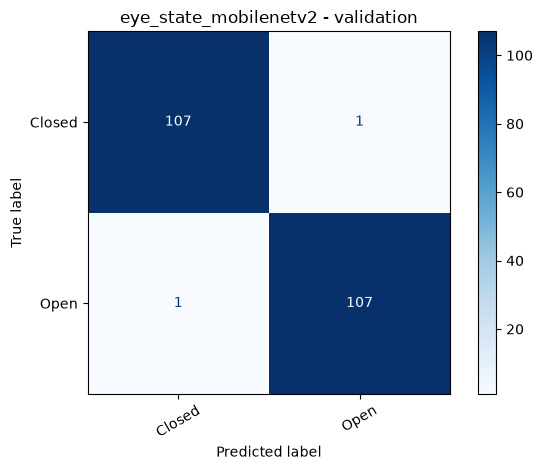


eye_state_mobilenetv2 - independent test: loss=0.0164, accuracy=0.9955
              precision    recall  f1-score   support

      Closed       1.00      0.99      1.00       110
        Open       0.99      1.00      1.00       110

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



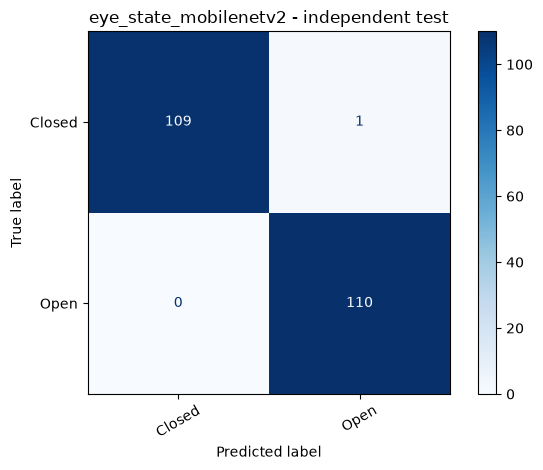

eye_state_mobilenetv2 training time: 3.1 minutes
Found 1013 images belonging to 2 classes.
Found 216 images belonging to 2 classes.
Found 219 images belonging to 2 classes.
Epoch 1/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 576ms/step - accuracy: 0.6071 - loss: 0.7292 - val_accuracy: 0.6667 - val_loss: 0.5442
Epoch 2/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 493ms/step - accuracy: 0.6594 - loss: 0.6094 - val_accuracy: 0.7361 - val_loss: 0.4974
Epoch 3/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 495ms/step - accuracy: 0.7019 - loss: 0.5556 - val_accuracy: 0.7454 - val_loss: 0.4985
Epoch 4/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 497ms/step - accuracy: 0.7058 - loss: 0.5462 - val_accuracy: 0.7361 - val_loss: 0.4632
Epoch 5/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 484ms/step - accuracy: 0.7532 - loss: 0.4894 - val_accuracy: 0.7500 - val_loss: 0.4627
Epoch 6/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 495ms/step - accuracy: 0.7493 - loss: 0.4980 - val_accuracy: 0.7778 - val_loss: 0.4399
Epoch 7/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 475ms/step 

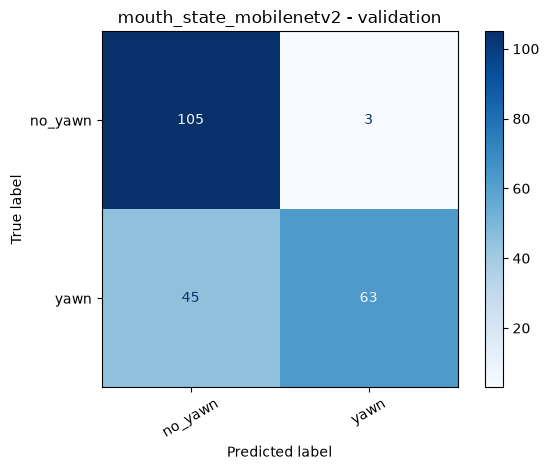


mouth_state_mobilenetv2 - independent test: loss=0.4505, accuracy=0.7443
              precision    recall  f1-score   support

     no_yawn       0.67      0.96      0.79       110
        yawn       0.93      0.52      0.67       109

    accuracy                           0.74       219
   macro avg       0.80      0.74      0.73       219
weighted avg       0.80      0.74      0.73       219



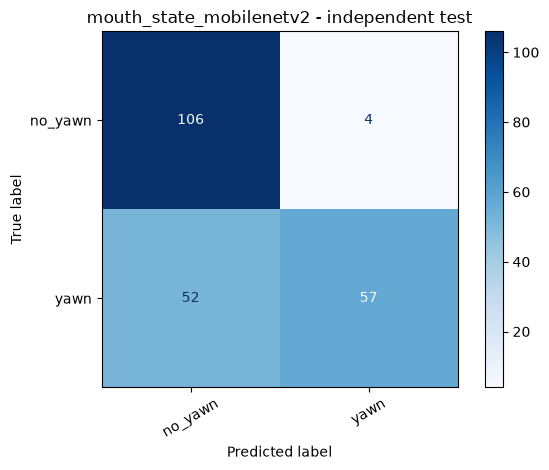

mouth_state_mobilenetv2 training time: 3.3 minutes


In [20]:
def binary_generators(class_names):
    train_aug = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=10, zoom_range=0.1, horizontal_flip=True,
        brightness_range=(0.8, 1.2)
    )
    plain = ImageDataGenerator(preprocessing_function=preprocess_input)
    options = dict(target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", classes=class_names)
    train = train_aug.flow_from_directory(TRAIN_DIR, shuffle=True, seed=SEED, **options)
    val = plain.flow_from_directory(VAL_DIR, shuffle=False, **options)
    test = plain.flow_from_directory(TEST_DIR, shuffle=False, **options)
    assert train.class_indices == val.class_indices == test.class_indices
    return train, val, test

def train_binary_task(task_name, class_names):
    train, val, test = binary_generators(class_names)
    model = build_mobilenet_classifier(2)
    stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    start = time.time()
    hist = model.fit(train, validation_data=val, epochs=12, callbacks=[stop])
    seconds = time.time() - start
    model.save(MODEL_DIR / f"{task_name}.keras")
    val_result = evaluate_classifier(model, val, f"{task_name} - validation")
    test_result = evaluate_classifier(model, test, f"{task_name} - independent test")
    print(f"{task_name} training time: {seconds/60:.1f} minutes")
    return model, hist, seconds, val_result, test_result

eye_model, eye_history, eye_seconds, eye_val_result, eye_test_result = train_binary_task(
    "eye_state_mobilenetv2", ["Closed", "Open"]
)
mouth_model, mouth_history, mouth_seconds, mouth_val_result, mouth_test_result = train_binary_task(
    "mouth_state_mobilenetv2", ["no_yawn", "yawn"]
)


## Model Comparison

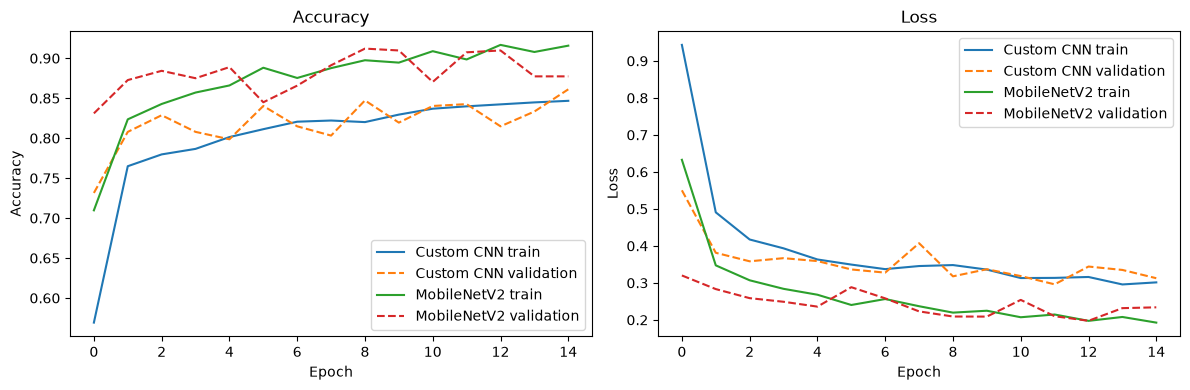

In [30]:
## Plot both models' learning curves.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, name in ((custom_history, "Custom CNN"), (mobilenet_history, "MobileNetV2")):
    axes[0].plot(hist.history["accuracy"], label=f"{name} train")
    axes[0].plot(hist.history["val_accuracy"], linestyle="--", label=f"{name} validation")
    axes[1].plot(hist.history["loss"], label=f"{name} train")
    axes[1].plot(hist.history["val_loss"], linestyle="--", label=f"{name} validation")
axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].set(title="Loss", xlabel="Epoch", ylabel="Loss")
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()


### Observation

MobileNetV2 achieved better generalisation performance and faster convergence compared to the Custom CNN model.
`

## Fatigue Classification Logic

Open      → Alert

No_Yawn   → Alert

Yawn      → Mild Fatigue

Closed    → Severe Fatigue

## Fatigue Progression Analysis

The fatigue progression curve illustrates how the driver's fatigue stage changes over time.

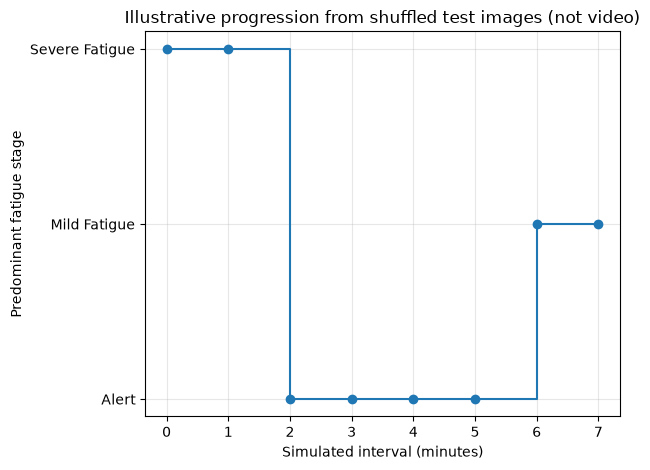

Simulated transitions (interval, from, to): [(2, 'Severe Fatigue', 'Alert'), (6, 'Alert', 'Mild Fatigue')]


In [23]:
stage_for_class = {"Open": 0, "no_yawn": 0, "yawn": 1, "Closed": 2}
stage_names = {0: "Alert", 1: "Mild Fatigue", 2: "Severe Fatigue"}
class_names = list(mobile_test.class_indices.keys())

# Predictions from each independent test image; this is not a video sequence.
test_prediction_names = [class_names[i] for i in mobile_test_result["predictions"]]
stages = np.array([stage_for_class[name] for name in test_prediction_names])

# A deterministic shuffled order simulates incoming frames. One frame per test image.
rng = np.random.default_rng(SEED)
sequence = stages
frames_per_interval = 60  # illustrative: 60 sampled frames represent one simulated minute
interval_stages = []
for start_idx in range(0, len(sequence), frames_per_interval):
    chunk = sequence[start_idx:start_idx + frames_per_interval]
    interval_stages.append(Counter(chunk.tolist()).most_common(1)[0][0])

transitions = []
for i in range(1, len(interval_stages)):
    if interval_stages[i] != interval_stages[i-1]:
        transitions.append((i, stage_names[interval_stages[i-1]], stage_names[interval_stages[i]]))

minutes = np.arange(len(interval_stages))
plt.step(minutes, interval_stages, where="post", marker="o")
plt.yticks([0, 1, 2], [stage_names[i] for i in [0, 1, 2]])
plt.xlabel("Simulated interval (minutes)")
plt.ylabel("Predominant fatigue stage")
plt.title("Illustrative progression from shuffled test images (not video)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Simulated transitions (interval, from, to):", transitions)


# Performance Analysis

## Custom CNN

### Advantages
- Simple architecture
- Learns task-specific features

### Limitations
- Slower training
- More prone to overfitting

## MobileNetV2

### Advantages
- Transfer learning
- Faster convergence
- Better accuracy

### Limitations
- Depends on pre-trained weights

## Error Cases
- Poor lighting
- Side face poses
- Partial eye closure

## Conclusion
MobileNetV2 achieved superior performance and is recommended for deployment.